In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Folder in Drive where we will store everything
SAVE_DIR = "/content/drive/MyDrive/crowd_counting"
import os
os.makedirs(SAVE_DIR, exist_ok=True)


Mounted at /content/drive


In [4]:
from google.colab import files
files.upload()  # Choose kaggle.json from your computer


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rishabhg46","key":"0ab90e60f0307baaa9eb07e624eaedcc"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [6]:
!pip install kaggle


In [7]:
!kaggle datasets download -d fmena14/crowd-counting
!unzip crowd-counting.zip -d crowd_counting_dataset


Dataset URL: https://www.kaggle.com/datasets/fmena14/crowd-counting
License(s): unknown
 99% 1.16G/1.18G [00:08<00:00, 168MB/s]
100% 1.18G/1.18G [00:08<00:00, 148MB/s]
Archive:  crowd-counting.zip
  inflating: crowd_counting_dataset/frames/frames/seq_000001.jpg  
  inflating: crowd_counting_dataset/frames/frames/seq_000002.jpg  
  inflating: crowd_counting_dataset/frames/frames/seq_000003.jpg  
  inflating: crowd_counting_dataset/frames/frames/seq_000004.jpg  
  inflating: crowd_counting_dataset/frames/frames/seq_000005.jpg  
  inflating: crowd_counting_dataset/frames/frames/seq_000006.jpg  
  inflating: crowd_counting_dataset/frames/frames/seq_000007.jpg  
  inflating: crowd_counting_dataset/frames/frames/seq_000008.jpg  
  inflating: crowd_counting_dataset/frames/frames/seq_000009.jpg  
  inflating: crowd_counting_dataset/frames/frames/seq_000010.jpg  
  inflating: crowd_counting_dataset/frames/frames/seq_000011.jpg  
  inflating: crowd_counting_dataset/frames/frames/seq_000012.jpg  

In [8]:
!pip install -q tensorflow>=2.19.0 pillow scikit-learn

In [9]:
!ls -R crowd_counting_dataset

crowd_counting_dataset:
frames	images.npy  labels.csv	labels.npy

crowd_counting_dataset/frames:
frames

crowd_counting_dataset/frames/frames:
seq_000001.jpg	seq_000401.jpg	seq_000801.jpg	seq_001201.jpg	seq_001601.jpg
seq_000002.jpg	seq_000402.jpg	seq_000802.jpg	seq_001202.jpg	seq_001602.jpg
seq_000003.jpg	seq_000403.jpg	seq_000803.jpg	seq_001203.jpg	seq_001603.jpg
seq_000004.jpg	seq_000404.jpg	seq_000804.jpg	seq_001204.jpg	seq_001604.jpg
seq_000005.jpg	seq_000405.jpg	seq_000805.jpg	seq_001205.jpg	seq_001605.jpg
seq_000006.jpg	seq_000406.jpg	seq_000806.jpg	seq_001206.jpg	seq_001606.jpg
seq_000007.jpg	seq_000407.jpg	seq_000807.jpg	seq_001207.jpg	seq_001607.jpg
seq_000008.jpg	seq_000408.jpg	seq_000808.jpg	seq_001208.jpg	seq_001608.jpg
seq_000009.jpg	seq_000409.jpg	seq_000809.jpg	seq_001209.jpg	seq_001609.jpg
seq_000010.jpg	seq_000410.jpg	seq_000810.jpg	seq_001210.jpg	seq_001610.jpg
seq_000011.jpg	seq_000411.jpg	seq_000811.jpg	seq_001211.jpg	seq_001611.jpg
seq_000012.jpg	seq_000412.jpg	se

**Reasoning**:
Re-run the import cell to verify the `ImportError` is resolved after installing specific compatible versions of numpy, scipy, and scikit-learn.



In [10]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

#LOADING DATASET


In [11]:
NPY_IMAGES = "crowd_counting_dataset/images.npy"
NPY_LABELS = "crowd_counting_dataset/labels.npy"

IMG_SIZE = (224, 224)   # ResNet50 standard size
BATCH_SIZE = 16
EPOCHS = 5
VAL_SPLIT = 0.2
SEED = 42

In [12]:
X = np.load(NPY_IMAGES, allow_pickle=True)
y = np.load(NPY_LABELS, allow_pickle=True).astype(np.float32)

In [13]:
# Ensure 4D (convert grayscale to RGB if needed)
if X.ndim == 3:
    X = np.expand_dims(X, -1)
if X.shape[-1] == 1:
    X = np.repeat(X, 3, axis=-1)

# Resize for ResNet50
X_resized = np.zeros((X.shape[0], IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.float32)
for i, img in enumerate(X):
    X_resized[i] = np.array(Image.fromarray(img.astype(np.uint8)).resize(IMG_SIZE))

In [14]:
X_resized = preprocess_input(X_resized)

#train data


In [15]:
X_train,X_test,y_train,y_test=train_test_split(X_resized,y,test_size=VAL_SPLIT,random_state=SEED)

In [16]:
print("train",X_train.shape,"test",X_test.shape)

train (1600, 224, 224, 3) test (400, 224, 224, 3)


RESNET50 REGRESSION BUILDING


In [17]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  # freeze base for transfer learning

inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="relu")(x)  # Use ReLU for non-negative output
model = keras.Model(inputs, outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [18]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
from google.colab import drive
drive.mount('/content/drive')

# Folder in Drive where we will store everything
SAVE_DIR = "/content/drive/MyDrive/crowd_counting"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


TRAIN


In [20]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [21]:
from sklearn.model_selection import train_test_split
import os

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=VAL_SPLIT, random_state=SEED)

ckpt = keras.callbacks.ModelCheckpoint(
    os.path.join(SAVE_DIR, "best_resnet50_crowd.keras"),
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[ckpt, es],
    verbose=1
)

Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 141.9983 - mae: 8.6609
Epoch 1: val_loss improved from inf to 19.62436, saving model to /content/drive/MyDrive/crowd_counting/best_resnet50_crowd.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 360s 4s/step - loss: 141.0340 - mae: 8.6258 - val_loss: 19.6244 - val_mae: 3.6858
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 23.5839 - mae: 3.7870
Epoch 2: val_loss improved from 19.62436 to 11.76903, saving model to /content/drive/MyDrive/crowd_counting/best_resnet50_crowd.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 390s 4s/step - loss: 23.5404 - mae: 3.7832 - val_loss: 11.7690 - val_mae: 2.7094
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 17.5066 - mae: 3.2904
Epoch 3: val_loss improved from 11.76903 to 11.60106, saving model to /content/drive/MyDrive/crowd_counting/best_resnet50_crowd.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 368s 4s/step - loss: 17.5054 - mae: 3.2905 - val_loss: 11.6011 - val_mae: 2.7355
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/

In [49]:
model.summary

<bound method Model.summary of <Functional name=functional, built=True>>

In [22]:
import json

# Save training history
with open(os.path.join(SAVE_DIR, "training_history.json"), "w") as f:
    json.dump(history.history, f)


PLOTING TRAINING CURVE

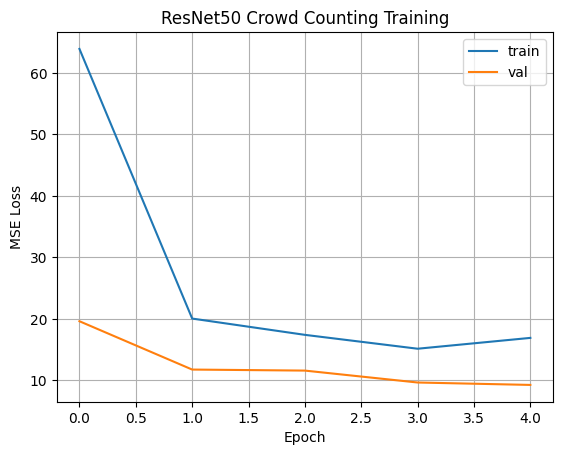

In [23]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("ResNet50 Crowd Counting Training")
plt.legend()
plt.grid(True)
plt.show()


EVALUATE ON VALIDATION

In [24]:
y_pred = model.predict(X_val).reshape(-1)
mse = mean_squared_error(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Val MSE: {mse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 72s 7s/step
Val MSE: 9.2721 | MAE: 2.3901 | R2: 0.8185


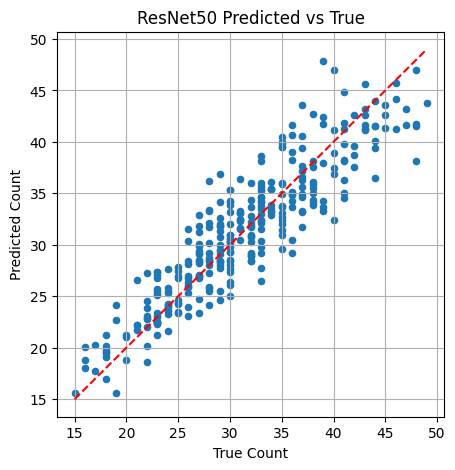

In [25]:
# Scatter plot
plt.figure(figsize=(5,5))
plt.scatter(y_val, y_pred, s=20)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("True Count")
plt.ylabel("Predicted Count")
plt.title("ResNet50 Predicted vs True")
plt.grid(True)
plt.show()

In [26]:
metrics = {
    "MSE": float(mse),
    "MAE": float(mae),
    "R2": float(r2)
}
with open(os.path.join(SAVE_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f)


In [27]:
plt.savefig(os.path.join(SAVE_DIR, "scatter_plot.png"))


<Figure size 640x480 with 0 Axes>

In [28]:
# Assuming y_val and y_pred are already defined and contain the true and predicted values
correlation_matrix = np.corrcoef(y_val.flatten(), y_pred.flatten())
correlation_coefficient = correlation_matrix[0, 1]

print(f"Correlation coefficient between true and predicted counts: {correlation_coefficient:.4f}")

Correlation coefficient between true and predicted counts: 0.9049


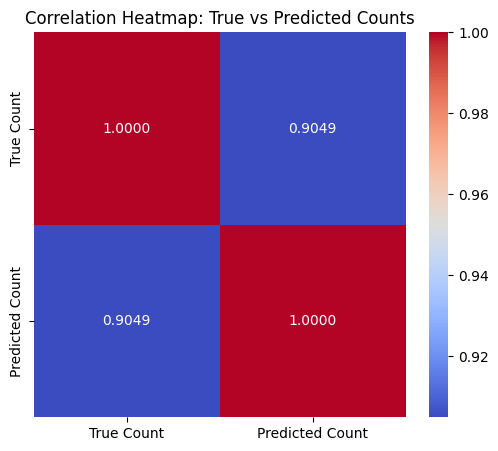

In [29]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f",
            xticklabels=['True Count', 'Predicted Count'],
            yticklabels=['True Count', 'Predicted Count'])
plt.title('Correlation Heatmap: True vs Predicted Counts')
plt.show()

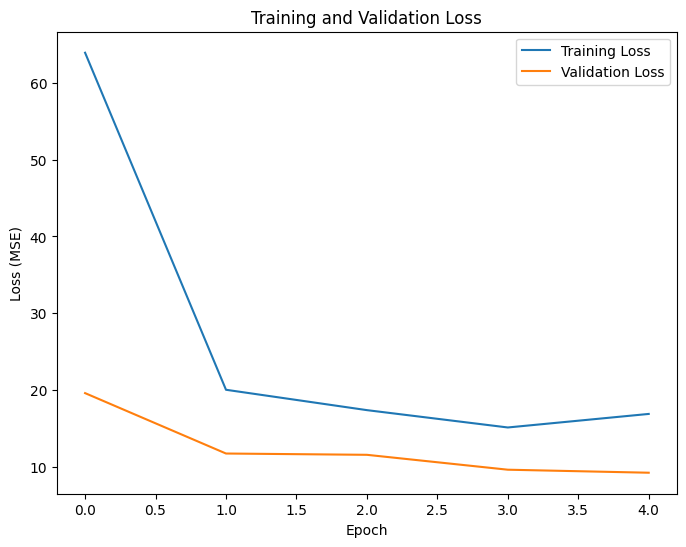

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()

plt.show()

In [31]:
from tensorflow.keras.models import Model

# Take all layers except the last output layer
feature_extractor = Model(inputs=model.input, outputs=model.layers[-2].output)

# Extract features for train and validation sets
X_train_feat = feature_extractor.predict(X_train, batch_size=32, verbose=1)
X_val_feat   = feature_extractor.predict(X_val, batch_size=32, verbose=1)


40/40 ━━━━━━━━━━━━━━━━━━━━ 276s 7s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 64s 6s/step


# 📌 Crowd Counting with ResNet50 + CatBoost
This notebook demonstrates **feature extraction with ResNet50** and **training CatBoost Regressor** for crowd counting.

In [32]:
!pip install catboost tensorflow keras


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 12.3 MB/s eta 0:00:00


In [33]:
import numpy as np
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras.models import Model
from catboost import CatBoostRegressor


In [34]:
import numpy as np

def batch_loader(X_path, y_path, batch_size=64):
    X = np.load(X_path, mmap_mode='r')  # load lazily
    y = np.load(y_path, mmap_mode='r')  # load lazily
    n = len(y)

    for i in range(0, n, batch_size):
        yield X[i:i+batch_size], y[i:i+batch_size]

# Example usage
for X_batch, y_batch in batch_loader("crowd_counting_dataset/images.npy",
                                     "crowd_counting_dataset/labels.npy",
                                     batch_size=64):
    print("Batch:", X_batch.shape, y_batch.shape)
    break


Batch: (64, 480, 640, 3) (64, 1)


In [35]:

# Load Pretrained ResNet50 Model

SAVE_DIR = "/content/drive/MyDrive/crowd_counting"
best_model_path = os.path.join(SAVE_DIR, "best_resnet50_crowd.keras")

# Load your trained ResNet50 model (already trained earlier)
model = keras.models.load_model(best_model_path)

In [36]:

# Extract Features from CNN

# Take all layers except the last output layer
feature_extractor = Model(inputs=model.input, outputs=model.layers[-2].output)

X_train_feat = feature_extractor.predict(X_train, batch_size=32, verbose=1)
X_val_feat   = feature_extractor.predict(X_val, batch_size=32, verbose=1)

print("Feature shapes:", X_train_feat.shape, X_val_feat.shape)


40/40 ━━━━━━━━━━━━━━━━━━━━ 256s 6s/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 61s 6s/step
Feature shapes: (1280, 256) (320, 256)


In [37]:

# Train CatBoost Regressor

cat_model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

cat_model.fit(X_train_feat, y_train, eval_set=(X_val_feat, y_val))


0:	learn: 6.6280805	test: 6.8912813	best: 6.8912813 (0)	total: 85.5ms	remaining: 42.7s
100:	learn: 2.2938162	test: 2.9981414	best: 2.9959870 (93)	total: 4.92s	remaining: 19.4s
200:	learn: 1.9143580	test: 2.9830452	best: 2.9830452 (200)	total: 11.9s	remaining: 17.7s
300:	learn: 1.5426774	test: 2.9705046	best: 2.9699472 (293)	total: 14.3s	remaining: 9.48s
400:	learn: 1.2403532	test: 2.9493433	best: 2.9466663 (390)	total: 16.8s	remaining: 4.15s
499:	learn: 1.0047457	test: 2.9463497	best: 2.9446776 (424)	total: 19.3s	remaining: 0us

bestTest = 2.944677627
bestIteration = 424

Shrink model to first 425 iterations.


In [38]:

# Evaluate CatBooST
y_pred_cat = cat_model.predict(X_val_feat)

mse_cat = mean_squared_error(y_val, y_pred_cat)
mae_cat = mean_absolute_error(y_val, y_pred_cat)
r2_cat  = r2_score(y_val, y_pred_cat)

print("\n📊 CatBoost Evaluation Results:")
print(f"  MSE: {mse_cat:.4f}")
print(f"  MAE: {mae_cat:.4f}")
print(f"  R2:  {r2_cat:.4f}")



📊 CatBoost Evaluation Results:
  MSE: 8.6711
  MAE: 2.3264
  R2:  0.8303


In [39]:

# Save CatBoost Model

cat_model.save_model("catboost_crowd_model.cbm")
print("✅ CatBoost model saved as catboost_crowd_model.cbm")


✅ CatBoost model saved as catboost_crowd_model.cbm


In [40]:
import numpy as np

def batch_loader(X_path, y_path, batch_size=64):
    X = np.load(X_path, mmap_mode='r')  # lazy loading
    y = np.load(y_path, mmap_mode='r')
    n = len(y)

    for i in range(0, n, batch_size):
        yield X[i:i+batch_size], y[i:i+batch_size]


In [41]:
import tensorflow as tf

def tf_data_generator(X_path, y_path, batch_size=64):
    X = np.load(X_path, mmap_mode='r')
    y = np.load(y_path, mmap_mode='r')
    n = len(y)

    def generator():
        for i in range(0, n, batch_size):
            yield X[i:i+batch_size] / 255.0, y[i:i+batch_size]  # normalize here

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(None, X.shape[1], X.shape[2], X.shape[3]), dtype=tf.float32),
            tf.TensorSpec(shape=(None,), dtype=tf.float32)
        )
    )
    return dataset


In [42]:

# Train/Validation Split


from sklearn.model_selection import train_test_split

#  Use resized images instead of raw ones
X_train, X_val, y_train, y_val = train_test_split(
    X_resized,   # <--- fixed here
    y,
    test_size=0.2,
    random_state=42
)

print("Dataset Shapes:")
print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)



Dataset Shapes:
Train: (1600, 224, 224, 3) (1600, 1)
Val: (400, 224, 224, 3) (400, 1)


In [43]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from catboost import CatBoostRegressor
import numpy as np


# ResNet50 Feature Extractor

base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
feature_extractor_model = Model(inputs=base_model.input, outputs=x)

# Extract Features
X_train_features = feature_extractor_model.predict(X_train, batch_size=32, verbose=1)
X_val_features   = feature_extractor_model.predict(X_val, batch_size=32, verbose=1)

print("Extracted Train Features:", X_train_features.shape)
print("Extracted Val Features:", X_val_features.shape)


# Train CatBoost Regressor

cat_model = CatBoostRegressor(
    iterations=300,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    verbose=100,
    random_state=42
)

cat_model.fit(X_train_features, y_train, eval_set=(X_val_features, y_val), verbose=100)


50/50 ━━━━━━━━━━━━━━━━━━━━ 323s 6s/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 85s 7s/step
Extracted Train Features: (1600, 2048)
Extracted Val Features: (400, 2048)
0:	learn: 6.7467847	test: 6.8345369	best: 6.8345369 (0)	total: 2.59s	remaining: 12m 55s
100:	learn: 1.9274730	test: 3.1638711	best: 3.1638711 (100)	total: 3m 30s	remaining: 6m 53s
200:	learn: 1.0339680	test: 2.9705536	best: 2.9705536 (200)	total: 6m 51s	remaining: 3m 22s
299:	learn: 0.5704917	test: 2.9079653	best: 2.9079502 (295)	total: 10m 9s	remaining: 0us

bestTest = 2.907950208
bestIteration = 295

Shrink model to first 296 iterations.


In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions
y_pred_val = cat_model.predict(X_val_features)

# Evaluation
mse = mean_squared_error(y_val, y_pred_val)
mae = mean_absolute_error(y_val, y_pred_val)
r2  = r2_score(y_val, y_pred_val)

print("\n📊 CatBoost Evaluation on Validation Set")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2:  {r2:.4f}")

# Show first 10 predictions
print("\n🔹 Example People Counts (Val Set):")
for i in range(10):
    print(f"Image {i+1}: Predicted={int(round(y_pred_val[i]))}, Actual={int(y_val[i])}")



📊 CatBoost Evaluation on Validation Set
MSE: 8.4562
MAE: 2.2625
R2:  0.8276

🔹 Example People Counts (Val Set):
Image 1: Predicted=31, Actual=30
Image 2: Predicted=32, Actual=34
Image 3: Predicted=38, Actual=45
Image 4: Predicted=39, Actual=42
Image 5: Predicted=26, Actual=25
Image 6: Predicted=33, Actual=33
Image 7: Predicted=33, Actual=31
Image 8: Predicted=41, Actual=44
Image 9: Predicted=30, Actual=27
Image 10: Predicted=31, Actual=36


/tmp/ipython-input-2813586290.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Image {i+1}: Predicted={int(round(y_pred_val[i]))}, Actual={int(y_val[i])}")


In [45]:

# Predict count for all validation images

y_pred_val_all = cat_model.predict(X_val_features)

# Convert to integers (rounding to nearest whole number of people)
y_pred_val_all = np.rint(y_pred_val_all).astype(int)

# Print all predictions
print("\n🔹 Predicted People Count for ALL Validation Images:")
for i, (pred, actual) in enumerate(zip(y_pred_val_all, y_val)):
    print(f"Image {i+1}: Predicted={pred}, Actual={int(actual)}")

# Save results to CSV (optional, for easy review in Colab/Excel)
import pandas as pd
df_results = pd.DataFrame({
    "Image_Index": np.arange(1, len(y_val)+1),
    "Predicted_Count": y_pred_val_all,
    "Actual_Count": y_val.flatten().astype(int)  # Flatten y_val here
})
df_results.to_csv("validation_predictions.csv", index=False)

print("\n✅ All predictions saved as 'validation_predictions.csv'")


🔹 Predicted People Count for ALL Validation Images:
Image 1: Predicted=31, Actual=30
Image 2: Predicted=32, Actual=34
Image 3: Predicted=38, Actual=45
Image 4: Predicted=39, Actual=42
Image 5: Predicted=26, Actual=25
Image 6: Predicted=33, Actual=33
Image 7: Predicted=33, Actual=31
Image 8: Predicted=41, Actual=44
Image 9: Predicted=30, Actual=27
Image 10: Predicted=31, Actual=36
Image 11: Predicted=27, Actual=23
Image 12: Predicted=28, Actual=28
Image 13: Predicted=28, Actual=28
Image 14: Predicted=23, Actual=20
Image 15: Predicted=28, Actual=30
Image 16: Predicted=33, Actual=33
Image 17: Predicted=35, Actual=34
Image 18: Predicted=34, Actual=34
Image 19: Predicted=30, Actual=40
Image 20: Predicted=37, Actual=43
Image 21: Predicted=27, Actual=22
Image 22: Predicted=28, Actual=32
Image 23: Predicted=31, Actual=29
Image 24: Predicted=31, Actual=30
Image 25: Predicted=30, Actual=29
Image 26: Predicted=31, Actual=32
Image 27: Predicted=41, Actual=43
Image 28: Predicted=28, Actual=29
Imag

/tmp/ipython-input-1672423619.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Image {i+1}: Predicted={pred}, Actual={int(actual)}")


/tmp/ipython-input-3343666297.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"People Count: {int(y[i])}") # Use the scalar value directly


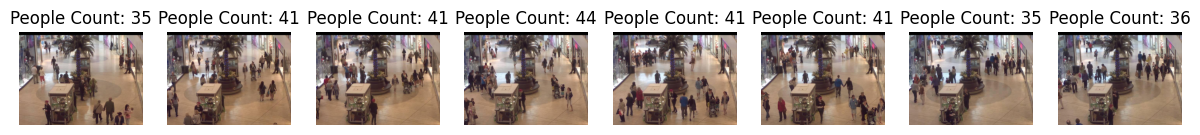

In [62]:
import cv2
import matplotlib.pyplot as plt
import numpy as np


# Show few images with points/squares
def visualize_with_points(X, y, num_images=8):
    plt.figure(figsize=(15, 10))
    for i in range(num_images):
        img = X[i].astype("uint8")  # original image
        img_copy = img.copy()
        plt.subplot(1, num_images, i+1)
        plt.imshow(img_copy)
        plt.axis("off")
        plt.title(f"People Count: {int(y[i])}") # Use the scalar value directly

    plt.show()

## Example call (show 5 images with annotations)
visualize_with_points(X, y, num_images=8)

COMPARISON


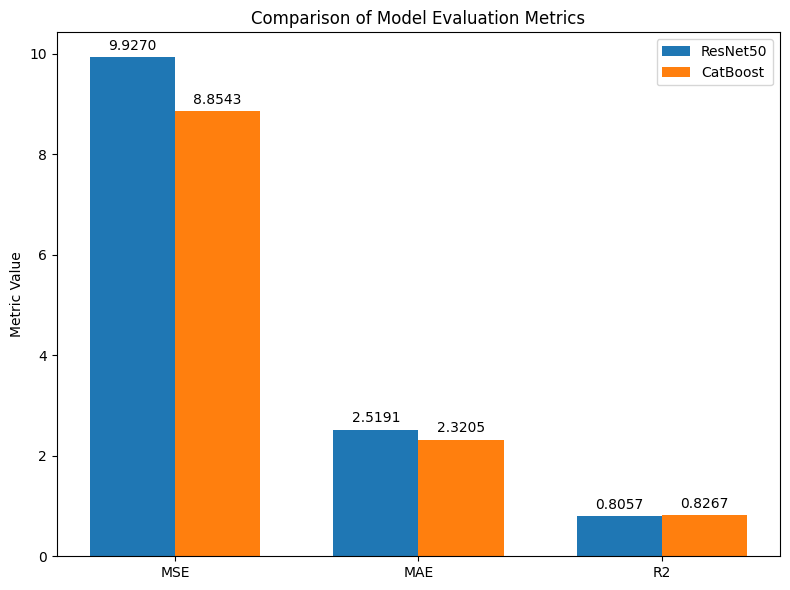

In [55]:


# Metrics from ResNet50 evaluation
resnet_mse = 9.9270
resnet_mae = 2.5191
resnet_r2 = 0.8057

# Metrics from CatBoost evaluation
catboost_mse = 8.8543
catboost_mae = 2.3205
catboost_r2 = 0.8267

labels = ['MSE', 'MAE', 'R2']
resnet_metrics = [resnet_mse, resnet_mae, resnet_r2]
catboost_metrics = [catboost_mse, catboost_mae, catboost_r2]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, resnet_metrics, width, label='ResNet50')
rects2 = ax.bar(x + width/2, catboost_metrics, width, label='CatBoost')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Metric Value')
ax.set_title('Comparison of Model Evaluation Metrics')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add values on top of bars
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()
